# Polynomial Interpolation of a Vector Field on a Convex Polygonal Domain

This notebook accompanies the paper **Junyan Chu, Shizuo Kaji: _Polynomial Interpolation of a Vector Field on a Convex Polygonal Domain_** (`arXiv:2602.01803`).

It follows the four examples:

1. interpolation on a regular pentagon,
2. reconstruction from sparse noisy velocities,
3. velocity fitting versus vorticity fitting, and
4. interpolation with additional linear constraints.

Run the notebook from the repository root with the **SageMath** kernel so that `src/` is importable.


In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Polygon as PolygonPatch
from matplotlib.path import Path as MplPath

from sage.all import QQ, cos, diff, pi, sin, vector

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    raise RuntimeError('Open this notebook from the repository root so that ./src is available.')

if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from hyperplane_arrangements import *

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print(f'Repository root: {ROOT}')
print('Using the SageMath kernel with the packaged hyperplane_arrangements module.')


Repository root: /Users/kaji/Library/CloudStorage/Dropbox/maple/HyperplaneArrangement
Using the SageMath kernel with the packaged hyperplane_arrangements module.


## Shared Helpers

In [2]:
def polygon_outline(vertices):
    poly = np.asarray(vertices, dtype=float)
    return np.vstack([poly, poly[0]])


def plot_polygon(ax, vertices, **kwargs):
    outline = polygon_outline(vertices)
    style = {'color': 'black', 'linewidth': 1.5}
    style.update(kwargs)
    ax.plot(outline[:, 0], outline[:, 1], **style)


def point_in_polygon(point, vertices):
    return MplPath(np.asarray(vertices, dtype=float)).contains_point(np.asarray(point, dtype=float))


def distance_to_segment(point, v0, v1):
    point = np.asarray(point, dtype=float)
    v0 = np.asarray(v0, dtype=float)
    v1 = np.asarray(v1, dtype=float)
    segment = v1 - v0
    seg_len_sq = float(segment.dot(segment))
    if seg_len_sq == 0:
        return float(np.linalg.norm(point - v0))
    t = float(np.clip((point - v0).dot(segment) / seg_len_sq, 0.0, 1.0))
    projection = v0 + t * segment
    return float(np.linalg.norm(point - projection))


def min_distance_to_boundary(point, vertices):
    vertices = np.asarray(vertices, dtype=float)
    return min(
        distance_to_segment(point, vertices[i], vertices[(i + 1) % len(vertices)])
        for i in range(len(vertices))
    )


def sample_random_points_in_polygon(
    vertices,
    n_points,
    seed=None,
    min_dist_from_boundary=0.0,
    min_dist_between_points=0.0,
    max_attempts_factor=3000,
):
    vertices = np.asarray(vertices, dtype=float)
    rng = np.random.default_rng(seed)
    mins = vertices.min(axis=0)
    maxs = vertices.max(axis=0)
    path = MplPath(vertices)
    points = []
    attempts = 0
    max_attempts = max_attempts_factor * n_points

    while len(points) < n_points and attempts < max_attempts:
        attempts += 1
        candidate = rng.uniform(mins, maxs)
        if not path.contains_point(candidate):
            continue
        if min_dist_from_boundary > 0 and min_distance_to_boundary(candidate, vertices) < min_dist_from_boundary:
            continue
        if min_dist_between_points > 0 and points:
            nearest = min(np.linalg.norm(candidate - np.asarray(existing)) for existing in points)
            if nearest < min_dist_between_points:
                continue
        points.append(candidate)

    if len(points) < n_points:
        raise RuntimeError(f'Only sampled {len(points)} of {n_points} requested points inside the polygon.')
    return np.asarray(points, dtype=float)


def evaluate_planar_field(A, vf, pt):
    gens = A.S.gens()
    subs = {gens[0]: float(pt[0]), gens[1]: float(pt[1])}
    if len(gens) > 2:
        subs[gens[2]] = 1
    return np.array([float(comp.subs(subs)) for comp in vf[:2]], dtype=float)


def evaluate_planar_field_batch(A, vf, points):
    pts = np.atleast_2d(np.asarray(points, dtype=float))
    return np.array([evaluate_planar_field(A, vf, pt) for pt in pts], dtype=float)


def evaluate_planar_vorticity(A, vf, pt):
    gens = A.S.gens()
    x, y = gens[0], gens[1]
    subs = {x: float(pt[0]), y: float(pt[1])}
    if len(gens) > 2:
        subs[gens[2]] = 1
    return float(diff(vf[1], x).subs(subs) - diff(vf[0], y).subs(subs))


def evaluate_planar_vorticity_batch(A, vf, points):
    pts = np.atleast_2d(np.asarray(points, dtype=float))
    return np.array([evaluate_planar_vorticity(A, vf, pt) for pt in pts], dtype=float)


def grid_inside_polygon(vertices, nx=90, ny=90, pad_fraction=0.08):
    vertices = np.asarray(vertices, dtype=float)
    mins = vertices.min(axis=0)
    maxs = vertices.max(axis=0)
    pad = pad_fraction * (maxs - mins)
    xs = np.linspace(mins[0] - pad[0], maxs[0] + pad[0], nx)
    ys = np.linspace(mins[1] - pad[1], maxs[1] + pad[1], ny)
    xx, yy = np.meshgrid(xs, ys)
    mask = MplPath(vertices).contains_points(np.column_stack((xx.ravel(), yy.ravel()))).reshape(xx.shape)
    return xs, ys, mask


def field_on_grid(evaluator, xs, ys, mask):
    xx, yy = np.meshgrid(xs, ys)
    vx = np.full(xx.shape, np.nan, dtype=float)
    vy = np.full(xx.shape, np.nan, dtype=float)
    valid_points = np.column_stack((xx[mask], yy[mask]))
    values = evaluator(valid_points)
    vx[mask] = values[:, 0]
    vy[mask] = values[:, 1]
    speed = np.hypot(vx, vy)
    return vx, vy, speed


def plot_stream_panel(ax, vertices, xs, ys, mask, evaluator, title, obs_points=None, obs_vectors=None, density=1.05):
    vx, vy, speed = field_on_grid(evaluator, xs, ys, mask)
    vx_masked = np.ma.array(vx, mask=~mask)
    vy_masked = np.ma.array(vy, mask=~mask)
    speed_masked = np.ma.array(speed, mask=~mask)

    stream = ax.streamplot(
        xs,
        ys,
        vx_masked,
        vy_masked,
        color=speed_masked,
        cmap='viridis',
        density=density,
        linewidth=1.15,
        arrowsize=0.9,
    )
    clip_patch = PolygonPatch(np.asarray(vertices, dtype=float), closed=True, facecolor='none', edgecolor='none')
    ax.add_patch(clip_patch)
    stream.lines.set_clip_path(clip_patch)
    stream.arrows.set_clip_path(clip_patch)

    plot_polygon(ax, vertices)
    if obs_points is not None and obs_vectors is not None:
        pts = np.asarray(obs_points, dtype=float)
        vecs = np.asarray(obs_vectors, dtype=float)

        # Plot predefined observation vectors
        ax.quiver(pts[:, 0], pts[:, 1], vecs[:, 0], vecs[:, 1], color='r')
        sing_points = pts[(vecs**2).sum(axis=1) < 1e-10]
        if len(sing_points) > 0:
            ax.scatter(sing_points[:, 0], sing_points[:, 1], marker='*', c='r', s=100)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)


def plot_vorticity_samples(ax, points, values, title, cmap='RdBu_r'):
    pts = np.asarray(points, dtype=float)
    values = np.asarray(values, dtype=float)
    vmax = float(np.max(np.abs(values)))
    if vmax == 0:
        vmax = 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    scatter = ax.scatter(
        pts[:, 0],
        pts[:, 1],
        c=values,
        cmap=cmap,
        norm=norm,
        s=60,
        edgecolors='black',
        linewidths=0.5,
    )
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    return scatter


def boundary_samples(vertices, samples_per_edge=120):
    vertices = np.asarray(vertices, dtype=float)
    points = []
    normals = []
    edge_s = []
    edge_lengths = np.linalg.norm(np.roll(vertices, -1, axis=0) - vertices, axis=1)
    cumulative = np.concatenate(([0.0], np.cumsum(edge_lengths)))
    total_length = cumulative[-1]

    for i in range(len(vertices)):
        p0 = vertices[i]
        p1 = vertices[(i + 1) % len(vertices)]
        tangent = p1 - p0
        normal = np.array([tangent[1], -tangent[0]], dtype=float)
        normal /= np.linalg.norm(normal)

        for s in np.linspace(0.0, 1.0, samples_per_edge, endpoint=False):
            points.append((1.0 - s) * p0 + s * p1)
            normals.append(normal)
            edge_s.append((cumulative[i] + s * edge_lengths[i]) / total_length)

    return np.asarray(points, dtype=float), np.asarray(normals, dtype=float), np.asarray(edge_s, dtype=float)


def monomial_exponents(degree):
    return [(a, d - a) for d in range(degree + 1) for a in range(d + 1)]


def monomial_matrix(points, degree):
    pts = np.asarray(points, dtype=float)
    return np.column_stack([(pts[:, 0] ** a) * (pts[:, 1] ** b) for a, b in monomial_exponents(degree)])


def velocity_design_matrix(points, degree):
    mon = monomial_matrix(points, degree)
    num_points, num_terms = mon.shape
    design = np.zeros((2 * num_points, 2 * num_terms), dtype=float)
    design[0::2, :num_terms] = mon
    design[1::2, num_terms:] = mon
    return design


def fit_unconstrained_polynomial(points, vectors, degree):
    design = velocity_design_matrix(points, degree)
    rhs = np.asarray(vectors, dtype=float).reshape(-1)
    return np.linalg.lstsq(design, rhs, rcond=None)[0]


def evaluate_polynomial_field(coeffs, points, degree):
    mon = monomial_matrix(points, degree)
    num_terms = mon.shape[1]
    coeffs = np.asarray(coeffs, dtype=float)
    return np.column_stack((mon @ coeffs[:num_terms], mon @ coeffs[num_terms:]))

def vorticity_on_grid(evaluator, xs, ys, mask):
    xx, yy = np.meshgrid(xs, ys)
    vort = np.full(xx.shape, np.nan, dtype=float)
    valid_points = np.column_stack((xx[mask], yy[mask]))
    vort[mask] = evaluator(valid_points)
    return vort


def plot_vorticity_panel(
    ax, vertices, xs, ys, mask, evaluator, title, obs_points=None, obs_values=None, norm=None, cmap='RdBu_r'
):
    vort = vorticity_on_grid(evaluator, xs, ys, mask)
    vort_masked = np.ma.array(vort, mask=~mask)

    if norm is None:
        vmax = np.ma.abs(vort_masked).max()
        if vmax == 0:
            vmax = 1.0
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    cf = ax.contourf(xs, ys, vort_masked, levels=50, cmap=cmap, norm=norm, extend='both')
    ax.contour(xs, ys, vort_masked, levels=10, colors='black', linewidths=0.5, alpha=0.3)

    plot_polygon(ax, vertices)

    if obs_points is not None and obs_values is not None:
        ax.scatter(
            obs_points[:, 0],
            obs_points[:, 1],
            c=obs_values,
            cmap=cmap,
            norm=norm,
            s=40,
            edgecolors='black',
            linewidths=0.5,
            zorder=3,
        )

    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    return cf


## 1. Interpolation on a Triangle

We model interpolation on a simple right triangle defined by $x \le 0$, $y \le 0$, and $x + y + 1 \ge 0$.

We select an exact tangent basis for this triangle and attempt to fit it to subsets of randomly selected observation points. 
The residuals show how finding a true interpolation (residual effectively zero) depends tightly on matching the dimension of the underlying tangent polynomial space. Polynomial degree strictly acts as a model capacity. For this geometric arrangement, polynomials of degree 2 provide 6 parameters which geometrically fit 3 vector observations perfectly, while polynomials of degree 3 provide 12 parameters which perfectly fit 6 observations!


In [ ]:
triangle_vertices = [
    (0.0, 0.0),
    (-1.0, 0.0),
    (0.0, -1.0),
]

# Two of the observations are now singular points (zero vectors)
triangle_observations = [
    ((-0.2, -0.2), (1.0, 0.5)),
    ((-0.5, -0.2), (0.0, 1.0)),
    ((-0.2, -0.5), (0.0, 0.0)),  # Singular point
    ((-0.8, -0.1), (2.0, 2.0)),
    ((-0.1, -0.8), (0.0, 0.0)),  # Singular point
    ((-0.4, -0.4), (0.5, -2.0)),
]

A_triangle = HyperplaneArrangement(vertices=triangle_vertices)
triangle_generators = A_triangle.minimal_generators()[1:]

xs, ys, mask = grid_inside_polygon(triangle_vertices, nx=80, ny=80)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# We evaluate increasing degrees and increasing number of observations
scenarios = [
    (3, 3), # Deg 3, 3 obs
    (3, 6), # Deg 3, 6 obs
    (4, 4), # Deg 4, 4 obs
    (4, 6), # Deg 4, 6 obs
]

for ax, (degree, n_obs) in zip(axes.ravel(), scenarios):
    Obs_now = dict(triangle_observations[:n_obs])
    mod_gens = triangle_generators.graded_component(degree)

    vf_fit, residual = fit_vf(A_triangle, Obs_now, mod_gens, verbose=False)

    print(f"dim {A_triangle.vf_dimension(degree)}") # dimension formula using syzygies

    print(f'Degree {degree} ({n_obs} obs) dim {len(mod_gens)}: residual = {residual:.4e}')

    pts_keys = np.array(list(Obs_now.keys()), dtype=float)
    pts_vals = np.array(list(Obs_now.values()), dtype=float)

    plot_stream_panel(
        ax,
        triangle_vertices,
        xs,
        ys,
        mask,
        lambda pts: evaluate_planar_field_batch(A_triangle, vf_fit, pts),
        f'Degree {degree}, Obs: {n_obs}\nresidual = {residual:.2e}',
        pts_keys,
        pts_vals,
    )

plt.tight_layout()
fig.savefig('degree_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. Reconstruction from Sparse Noisy Velocities

We start from a synthetic tangential field on an irregular hexagon, sample `48` interior velocities, perturb them with Gaussian noise of standard deviation `0.01`, and compare two models:

1. an unconstrained polynomial vector field of degree at most `7`, and
2. a degree-`7` fit constrained to be tangential on every edge.


In [10]:
def hom_line(p1, p2):
    (x1, y1), (x2, y2) = p1, p2
    return QQ(y1 - y2), QQ(x2 - x1), QQ(x1*y2 - x2*y1)

def unconstrained_basis(A, degree):
    v = A.S.gens()[:-1]
    G_unc = []
    for d in range(degree + 1):
        for a in range(d + 1):
            p = (v[0]**a) * (v[1]**(d - a))
            G_unc.append(vector([p, 0]))
            G_unc.append(vector([0, p]))
    return G_unc

def sweep_boundary_demo(A, vf_true, vertices, boundary_generators, degrees, num_trials=5, num_observations=48, noise=0.01):
    boundary_points, boundary_normals, _ = boundary_samples(vertices, samples_per_edge=120)
    test_points = sample_random_points_in_polygon(vertices, 2200, seed=int(4321))
    ground_truth = evaluate_planar_field_batch(A, vf_true, test_points)
    results = []

    for degree in degrees:
        mod_gens = boundary_generators.graded_component(degree)
        G_unc = unconstrained_basis(A, degree)
        stats = {'unc_error': [], 'tgt_error': [], 'unc_leak': [], 'tgt_leak': []}

        for trial in range(num_trials):
            obs_points = sample_random_points_in_polygon(vertices, num_observations, seed=int(3100 + 97 * degree + trial))
            obs_vectors = evaluate_planar_field_batch(A, vf_true, obs_points)
            noise_rng = np.random.default_rng(int(9100 + 131 * degree + trial))
            obs_vectors += noise_rng.normal(scale=noise, size=obs_vectors.shape)
            Obs = {tuple(pt): tuple(vec) for pt, vec in zip(obs_points, obs_vectors)}

            unc_fit, _ = fit_vf(A, Obs, G_unc, verbose=False)
            tgt_fit, _ = fit_vf(A, Obs, mod_gens, verbose=False)

            unc_pred = evaluate_planar_field_batch(A, unc_fit, test_points)
            tgt_pred = evaluate_planar_field_batch(A, tgt_fit, test_points)
            stats['unc_error'].append(float(np.sqrt(np.mean((unc_pred - ground_truth) ** 2))))
            stats['tgt_error'].append(float(np.sqrt(np.mean((tgt_pred - ground_truth) ** 2))))

            unc_boundary = evaluate_planar_field_batch(A, unc_fit, boundary_points)
            tgt_boundary = evaluate_planar_field_batch(A, tgt_fit, boundary_points)
            stats['unc_leak'].append(float(np.mean(np.abs(np.sum(unc_boundary * boundary_normals, axis=1)))))
            stats['tgt_leak'].append(float(np.mean(np.abs(np.sum(tgt_boundary * boundary_normals, axis=1)))))

        results.append((degree, stats))
    return results

unconstrained dimension 72
tangential dimension 24
unconstrained error = 0.2165
tangential error    = 0.0048
unconstrained leak  = 0.3501
tangential leak     = 4.9566e-14


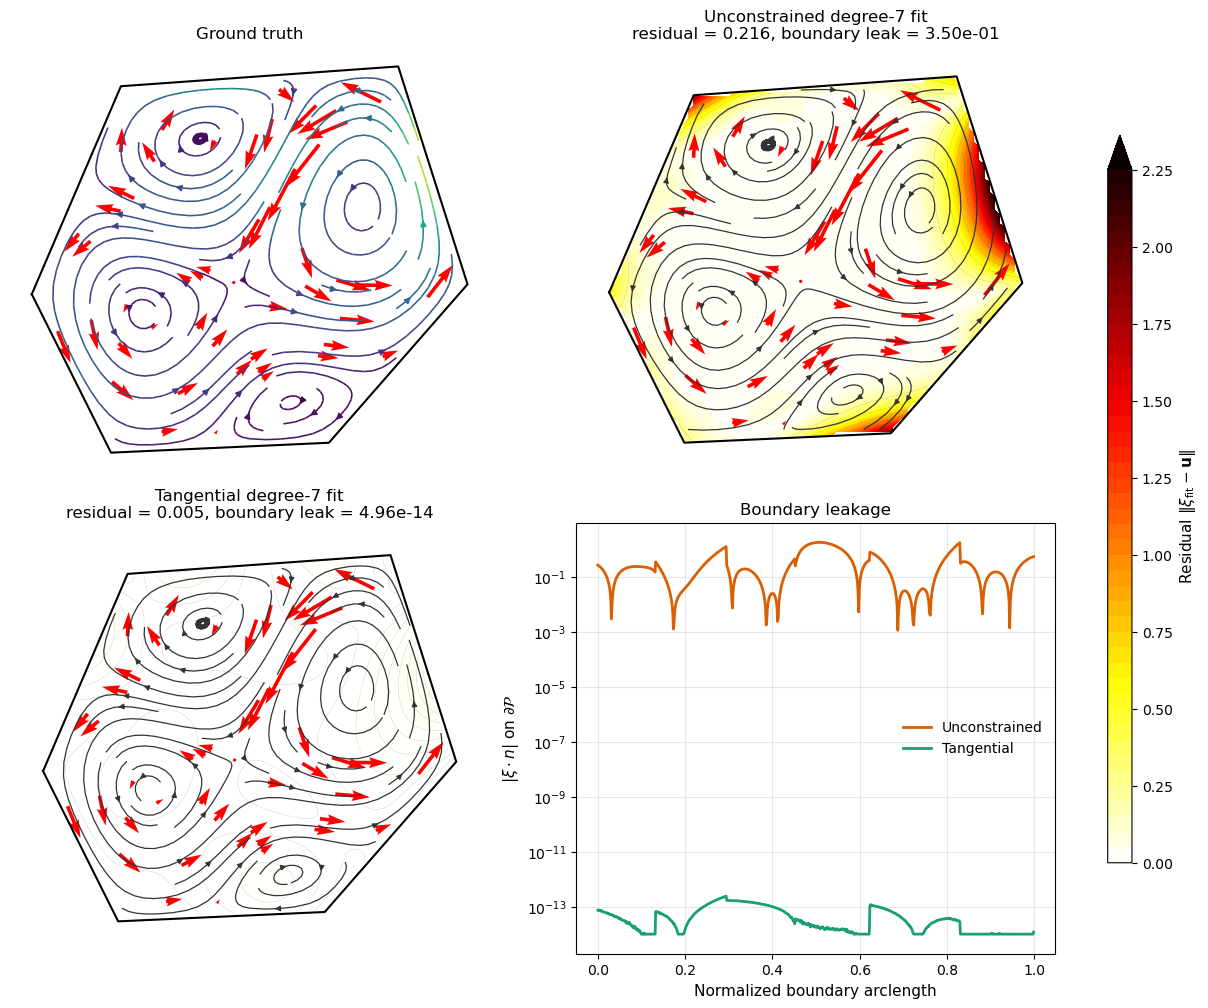

In [15]:
boundary_vertices = np.array([
    (-1.10, -0.20),
    (-0.70, -1.00),
    (0.40, -0.95),
    (1.10, -0.15),
    (0.75, 0.95),
    (-0.65, 0.85),
], dtype=float)

lines_boundary = [[0, 0, 1]] + [list(hom_line(boundary_vertices[i], boundary_vertices[(i+1)%6])) for i in range(6)]
A_boundary = HyperplaneArrangement(matrix(QQ, lines_boundary))
boundary_generators = A_boundary.minimal_generators()[1:]

x, y, z = A_boundary.S.gens()
Q_aff = A_boundary.Q.subs({z: 1})
q = 0.55*x**2 + 0.80*x*y - 0.35*y**2 + 0.18*x - 0.12*y + 0.08
psi = q * Q_aff
vf_true_unscaled = vector([diff(psi, y), -diff(psi, x)])

scale_points = sample_random_points_in_polygon(boundary_vertices, 2500, seed=int(12345))
unscaled_eval = evaluate_planar_field_batch(A_boundary, vf_true_unscaled, scale_points)
velocity_scale = float(np.sqrt(np.mean(unscaled_eval ** 2)))
vf_true = vf_true_unscaled / velocity_scale
boundary_degree = 7
true_degree = 7

boundary_obs_points = sample_random_points_in_polygon(boundary_vertices, 48, seed=int(1000))
boundary_obs_vectors = evaluate_planar_field_batch(A_boundary, vf_true, boundary_obs_points)
boundary_rng = np.random.default_rng(int(1000))
boundary_obs_vectors += boundary_rng.normal(scale=0.01, size=boundary_obs_vectors.shape)
Obs_boundary = {tuple(pt): tuple(vec) for pt, vec in zip(boundary_obs_points, boundary_obs_vectors)}

G_unc = unconstrained_basis(A_boundary, boundary_degree)
unc_fit, _ = fit_vf(A_boundary, Obs_boundary, G_unc, verbose=False)
print(f"unconstrained dimension {len(G_unc)}")
mod_gens = boundary_generators.graded_component(boundary_degree)
tgt_fit, _ = fit_vf(A_boundary, Obs_boundary, mod_gens, verbose=False)
print(f"tangential dimension {len(mod_gens)}")

boundary_points, boundary_normals, boundary_s = boundary_samples(boundary_vertices, samples_per_edge=120)
dense_points = sample_random_points_in_polygon(boundary_vertices, 2500, seed=int(1234))

ground_truth_dense = evaluate_planar_field_batch(A_boundary, vf_true, dense_points)
unc_dense = evaluate_planar_field_batch(A_boundary, unc_fit, dense_points)
tgt_dense = evaluate_planar_field_batch(A_boundary, tgt_fit, dense_points)

unc_error = float(np.sqrt(np.mean((unc_dense - ground_truth_dense) ** 2)))
tgt_error = float(np.sqrt(np.mean((tgt_dense - ground_truth_dense) ** 2)))

unc_boundary = evaluate_planar_field_batch(A_boundary, unc_fit, boundary_points)
tgt_boundary = evaluate_planar_field_batch(A_boundary, tgt_fit, boundary_points)
unc_leak = np.abs(np.sum(unc_boundary * boundary_normals, axis=1))
tgt_leak = np.abs(np.sum(tgt_boundary * boundary_normals, axis=1))

print(f'unconstrained error = {unc_error:.4f}')
print(f'tangential error    = {tgt_error:.4f}')
print(f'unconstrained leak  = {unc_leak.mean():.4f}')
print(f'tangential leak     = {tgt_leak.mean():.4e}')

xs, ys, mask = grid_inside_polygon(boundary_vertices, nx=95, ny=95)

# --- Compute pointwise residual magnitude on the grid ---
def residual_on_grid(A, vf_fit, vf_true, xs, ys, mask):
    xx, yy = np.meshgrid(xs, ys)
    res = np.full(xx.shape, np.nan, dtype=float)
    valid_points = np.column_stack((xx[mask], yy[mask]))
    fit_vals = evaluate_planar_field_batch(A, vf_fit, valid_points)
    true_vals = evaluate_planar_field_batch(A, vf_true, valid_points)
    res[mask] = np.sqrt(np.sum((fit_vals - true_vals)**2, axis=1))
    return res

unc_residual_grid = residual_on_grid(A_boundary, unc_fit, vf_true, xs, ys, mask)
tgt_residual_grid = residual_on_grid(A_boundary, tgt_fit, vf_true, xs, ys, mask)
res_vmax = max(np.nanmax(unc_residual_grid), np.nanmax(tgt_residual_grid))

def plot_stream_with_residual(ax, vertices, xs, ys, mask, evaluator, res_grid, res_vmax, title,
                              obs_points=None, obs_vectors=None, density=1.05):
    """Streamlines overlaid on a residual heatmap."""
    vx, vy, speed = field_on_grid(evaluator, xs, ys, mask)
    vx_masked = np.ma.array(vx, mask=~mask)
    vy_masked = np.ma.array(vy, mask=~mask)
    res_masked = np.ma.array(res_grid, mask=~mask)

    # Background: residual heatmap
    cf = ax.contourf(xs, ys, res_masked, levels=50, cmap='hot_r', vmin=0, vmax=res_vmax, extend='max')
    ax.contour(xs, ys, res_masked, levels=10, colors='black', linewidths=0.3, alpha=0.2)

    # Overlay: streamlines in a single colour
    clip_patch = PolygonPatch(np.asarray(vertices, dtype=float), closed=True, facecolor='none', edgecolor='none')
    ax.add_patch(clip_patch)
    stream = ax.streamplot(xs, ys, vx_masked, vy_masked, color='#333333',
                           density=density, linewidth=0.9, arrowsize=0.8)
    stream.lines.set_clip_path(clip_patch)
    stream.arrows.set_clip_path(clip_patch)

    plot_polygon(ax, vertices)
    if obs_points is not None and obs_vectors is not None:
        pts = np.asarray(obs_points, dtype=float)
        vecs = np.asarray(obs_vectors, dtype=float)
        ax.quiver(pts[:, 0], pts[:, 1], vecs[:, 0], vecs[:, 1], color='red')
        sing_points = pts[(vecs**2).sum(axis=1) < 1e-10]
        if len(sing_points) > 0:
            ax.scatter(sing_points[:, 0], sing_points[:, 1], marker='*', c='red', s=100)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    return cf

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

plot_stream_panel(
    axes[0, 0],
    boundary_vertices,
    xs,
    ys,
    mask,
    lambda pts: evaluate_planar_field_batch(A_boundary, vf_true, pts),
    'Ground truth',
    boundary_obs_points,
    boundary_obs_vectors,
)

cf = plot_stream_with_residual(
    axes[0, 1],
    boundary_vertices,
    xs,
    ys,
    mask,
    lambda pts: evaluate_planar_field_batch(A_boundary, unc_fit, pts),
    unc_residual_grid,
    res_vmax,
    f'Unconstrained degree-{boundary_degree} fit\nresidual = {unc_error:.3f}, boundary leak = {unc_leak.mean():.2e}',
    boundary_obs_points,
    boundary_obs_vectors,
)

plot_stream_with_residual(
    axes[1, 0],
    boundary_vertices,
    xs,
    ys,
    mask,
    lambda pts: evaluate_planar_field_batch(A_boundary, tgt_fit, pts),
    tgt_residual_grid,
    res_vmax,
    f'Tangential degree-{boundary_degree} fit\nresidual = {tgt_error:.3f}, boundary leak = {tgt_leak.mean():.2e}',
    boundary_obs_points,
    boundary_obs_vectors,
)

plt.colorbar(cf, ax=[axes[0, 1], axes[1, 0]],
             label='Residual $\\|\\xi_{\\mathrm{fit}} - \\mathbf{u}\\|$',
             shrink=0.8, aspect=30)

eps = 1e-14
axes[1, 1].semilogy(boundary_s, np.maximum(unc_leak, eps), label='Unconstrained', linewidth=2.0, color='#d95f02')
axes[1, 1].semilogy(boundary_s, np.maximum(tgt_leak, eps), label='Tangential', linewidth=2.0, color='#1b9e77')
axes[1, 1].set_xlabel('Normalized boundary arclength')
axes[1, 1].set_ylabel(r'$|\xi \cdot n|$ on $\partial \mathcal{P}$')
axes[1, 1].set_title('Boundary leakage')
axes[1, 1].grid(True, which='both', alpha=0.3)
axes[1, 1].legend(frameon=False)

plt.show()

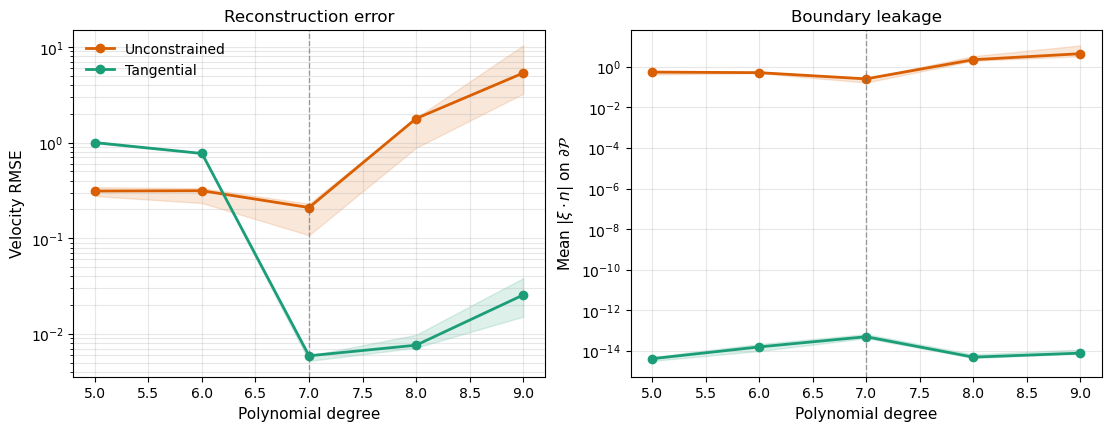

In [6]:
boundary_sweep = sweep_boundary_demo(
    A_boundary,
    vf_true,
    boundary_vertices,
    boundary_generators,
    degrees=[5, 6, 7, 8, 9],
    num_trials=5,
    num_observations=48,
    noise=0.01,
)

def sweep_stat(results, key, reducer):
    return np.array([reducer(item[1][key]) for item in results], dtype=float)

degrees = np.array([item[0] for item in boundary_sweep], dtype=int)
unc_error_med = sweep_stat(boundary_sweep, 'unc_error', np.median)
tgt_error_med = sweep_stat(boundary_sweep, 'tgt_error', np.median)
unc_error_lo = sweep_stat(boundary_sweep, 'unc_error', lambda x: np.quantile(x, 0.25))
unc_error_hi = sweep_stat(boundary_sweep, 'unc_error', lambda x: np.quantile(x, 0.75))
tgt_error_lo = sweep_stat(boundary_sweep, 'tgt_error', lambda x: np.quantile(x, 0.25))
tgt_error_hi = sweep_stat(boundary_sweep, 'tgt_error', lambda x: np.quantile(x, 0.75))

unc_leak_med = sweep_stat(boundary_sweep, 'unc_leak', np.median)
tgt_leak_med = sweep_stat(boundary_sweep, 'tgt_leak', np.median)
unc_leak_lo = sweep_stat(boundary_sweep, 'unc_leak', lambda x: np.quantile(x, 0.25))
unc_leak_hi = sweep_stat(boundary_sweep, 'unc_leak', lambda x: np.quantile(x, 0.75))
tgt_leak_lo = sweep_stat(boundary_sweep, 'tgt_leak', lambda x: np.quantile(x, 0.25))
tgt_leak_hi = sweep_stat(boundary_sweep, 'tgt_leak', lambda x: np.quantile(x, 0.75))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

axes[0].semilogy(degrees, unc_error_med, 'o-', color='#d95f02', linewidth=2.0, label='Unconstrained')
axes[0].fill_between(degrees, unc_error_lo, unc_error_hi, color='#d95f02', alpha=0.15)
axes[0].semilogy(degrees, tgt_error_med, 'o-', color='#1b9e77', linewidth=2.0, label='Tangential')
axes[0].fill_between(degrees, tgt_error_lo, tgt_error_hi, color='#1b9e77', alpha=0.15)
axes[0].axvline(true_degree, color='#666666', linestyle='--', linewidth=1.0, alpha=0.6)
axes[0].set_xlabel('Polynomial degree')
axes[0].set_ylabel('Velocity RMSE')
axes[0].set_title('Reconstruction error')
axes[0].grid(True, which='both', alpha=0.3)
axes[0].legend(frameon=False)

axes[1].semilogy(degrees, unc_leak_med, 'o-', color='#d95f02', linewidth=2.0, label='Unconstrained')
axes[1].fill_between(degrees, unc_leak_lo, unc_leak_hi, color='#d95f02', alpha=0.15)
axes[1].semilogy(degrees, tgt_leak_med, 'o-', color='#1b9e77', linewidth=2.0, label='Tangential')
axes[1].fill_between(degrees, tgt_leak_lo, tgt_leak_hi, color='#1b9e77', alpha=0.15)
axes[1].axvline(true_degree, color='#666666', linestyle='--', linewidth=1.0, alpha=0.6)
axes[1].set_xlabel('Polynomial degree')
axes[1].set_ylabel(r'Mean $|\xi \cdot n|$ on $\partial \mathcal{P}$')
axes[1].set_title('Boundary leakage')
axes[1].grid(True, which='both', alpha=0.3)

plt.show()

## 3. Velocity Fitting Versus Vorticity Fitting

We compare fitting from two data types:

1. noisy velocity samples, and
2. noisy scalar vorticity samples.

We sample `50` noisy observations from a vortex-based field and compare fits for `4 \leq k \leq 10`.
In the figure below, the top row shows the velocity fields recovered from velocity data, while the bottom row compares the vorticity recovered from vorticity-only fits at the same sample points.


In [5]:
comparison_hexagon = [
    (0.25, 0.15),
    (0.75, 0.10),
    (0.95, 0.55),
    (0.70, 0.90),
    (0.30, 0.85),
    (0.10, 0.40),
]

A_compare = HyperplaneArrangement(vertices=comparison_hexagon)
compare_generators = A_compare.minimal_generators()[1:]

def vortex_velocity(point, centers, strengths):
    point = np.asarray(point, dtype=float)
    velocity = np.zeros(2, dtype=float)
    for center, strength in zip(centers, strengths):
        dx = point[0] - center[0]
        dy = point[1] - center[1]
        r2 = dx ** 2 + dy ** 2
        if r2 > 1e-6:
            factor = strength / (2 * np.pi * r2)
            velocity[0] += -dy * factor
            velocity[1] += dx * factor
    return velocity


true_degree = 10
vortex_centers = [(0.35, 0.30)]
vortex_strengths = np.random.default_rng(int(42)).normal(scale=2.0, size=len(vortex_centers))

fitting_points = sample_random_points_in_polygon(
    comparison_hexagon,
    100,
    min_dist_from_boundary=0.04,
    min_dist_between_points=0.05,
)
Obs_vortex_seed = {
    tuple(point): tuple(vortex_velocity(point, vortex_centers, vortex_strengths))
    for point in fitting_points
}
vf_true, true_projection_residual = fit_vf(
    A_compare,
    Obs_vortex_seed,
    compare_generators.graded_component(true_degree),
    verbose=False,
)

print(f'Projected ground-truth degree: {true_degree}')
print(f'Projection residual onto the polynomial model: {true_projection_residual:.4e}')

measurement_points = sample_random_points_in_polygon(
    comparison_hexagon,
    50,
    min_dist_from_boundary=0.03,
    min_dist_between_points=0.06,
)
rng_measure = np.random.default_rng(int(12345))

true_velocity_samples = evaluate_planar_field_batch(A_compare, vf_true, measurement_points)
true_vorticity_samples = evaluate_planar_vorticity_batch(A_compare, vf_true, measurement_points)

Obs_velocity = {}
Obs_vorticity = {}
for point, velocity_value, vorticity_value in zip(measurement_points, true_velocity_samples, true_vorticity_samples):
    Obs_velocity[tuple(point)] = tuple(velocity_value + rng_measure.normal(scale=0.01, size=2))
    Obs_vorticity[tuple(point)] = float(vorticity_value + rng_measure.normal(scale=0.01))

degrees_compare = list(range(4, 11))
fits_from_velocity = {}
fits_from_vorticity = {}
comparison_metrics = {}

for degree in degrees_compare:
    mod_gens = compare_generators.graded_component(degree)
    fit_vel, residual_vel = fit_vf(A_compare, Obs_velocity, mod_gens, verbose=False)
    fit_vort, residual_vort = fit_vorticity(A_compare, Obs_vorticity, mod_gens, verbose=False)

    vel_from_vel = evaluate_planar_field_batch(A_compare, fit_vel, measurement_points)
    vel_from_vort = evaluate_planar_field_batch(A_compare, fit_vort, measurement_points)
    vort_from_vel = evaluate_planar_vorticity_batch(A_compare, fit_vel, measurement_points)
    vort_from_vort = evaluate_planar_vorticity_batch(A_compare, fit_vort, measurement_points)

    fits_from_velocity[degree] = fit_vel
    fits_from_vorticity[degree] = fit_vort
    comparison_metrics[degree] = {
        'velocity_residual': residual_vel,
        'vorticity_residual': residual_vort,
        'velocity_rmse_from_velocity': float(np.sqrt(np.mean((vel_from_vel - true_velocity_samples) ** 2))),
        'velocity_rmse_from_vorticity': float(np.sqrt(np.mean((vel_from_vort - true_velocity_samples) ** 2))),
        'vorticity_rmse_from_velocity': float(np.sqrt(np.mean((vort_from_vel - true_vorticity_samples) ** 2))),
        'vorticity_rmse_from_vorticity': float(np.sqrt(np.mean((vort_from_vort - true_vorticity_samples) ** 2))),
    }

    metrics = comparison_metrics[degree]
    print(
        f"k={degree}: "
        f"velocity RMSE {metrics['velocity_rmse_from_velocity']:.4e} (from velocity) vs "
        f"{metrics['velocity_rmse_from_vorticity']:.4e} (from vorticity); "
        f"vorticity RMSE {metrics['vorticity_rmse_from_velocity']:.4e} (from velocity) vs "
        f"{metrics['vorticity_rmse_from_vorticity']:.4e} (from vorticity)"
    )

Projected ground-truth degree: 10
Projection residual onto the polynomial model: 8.6348e+00
k=4: velocity RMSE 3.8034e-01 (from velocity) vs 6.6762e-01 (from vorticity); vorticity RMSE 8.3333e+00 (from velocity) vs 8.2177e+00 (from vorticity)
k=5: velocity RMSE 3.1395e-01 (from velocity) vs 2.0946e+00 (from vorticity); vorticity RMSE 8.1080e+00 (from velocity) vs 6.5219e+00 (from vorticity)
k=6: velocity RMSE 2.8976e-01 (from velocity) vs 1.1676e+01 (from vorticity); vorticity RMSE 8.2428e+00 (from velocity) vs 5.3950e+00 (from vorticity)
k=7: velocity RMSE 2.0372e-01 (from velocity) vs 1.8536e+02 (from vorticity); vorticity RMSE 7.0075e+00 (from velocity) vs 2.2374e+00 (from vorticity)
k=8: velocity RMSE 1.2927e-01 (from velocity) vs 1.3831e+08 (from vorticity); vorticity RMSE 8.0474e+00 (from velocity) vs 2.0466e-01 (from vorticity)
k=9: velocity RMSE 7.2390e-02 (from velocity) vs 2.4212e+03 (from vorticity); vorticity RMSE 8.7818e+00 (from velocity) vs 5.9195e-02 (from vorticity)
k=

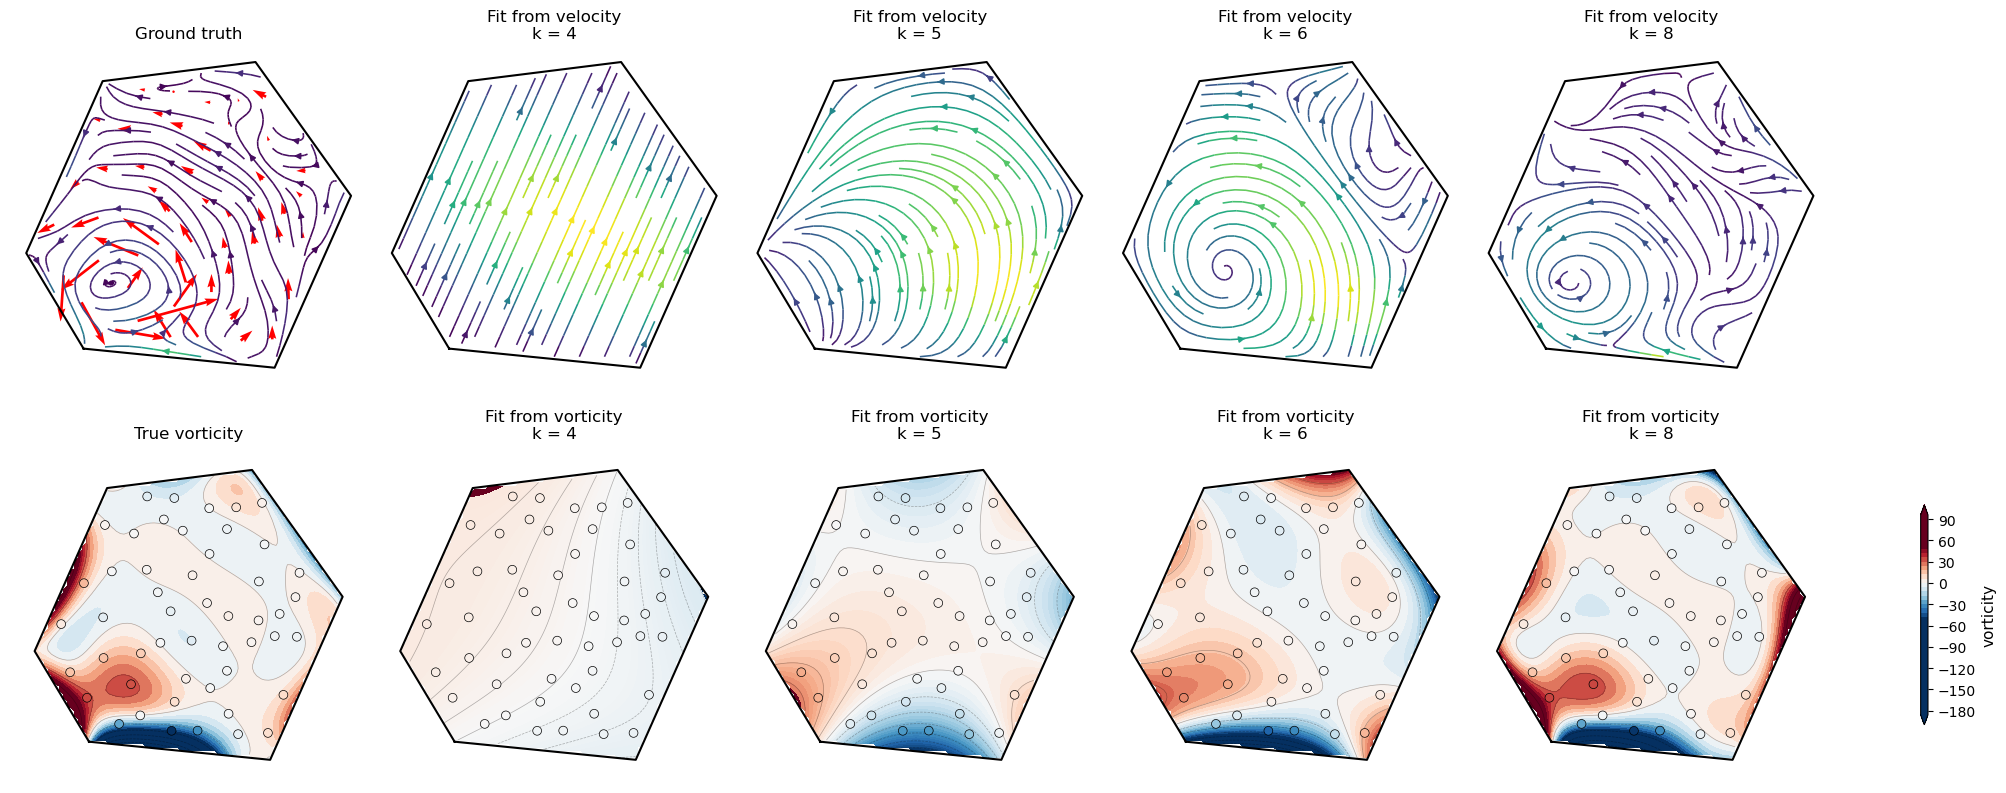

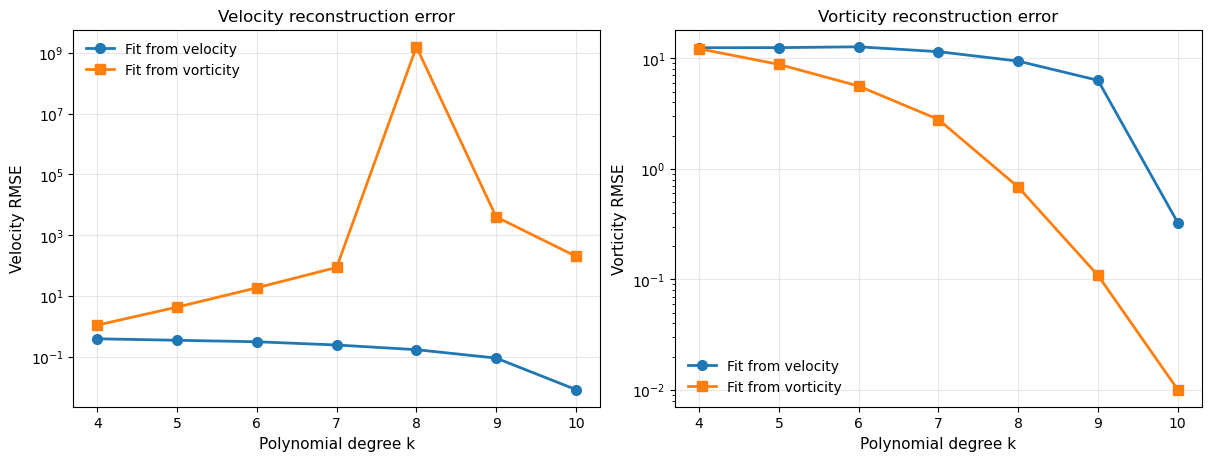

In [ ]:
selected_degrees = [4, 5, 6, 8]
xs, ys, mask = grid_inside_polygon(comparison_hexagon, nx=95, ny=95)
noisy_velocity_points = np.array(list(Obs_velocity.keys()), dtype=float)
noisy_velocity_vectors = np.array(list(Obs_velocity.values()), dtype=float)

# Compute max scale for vorticity normalization across all plots in the row
vort_max = float(np.max(np.abs(true_vorticity_samples)))
for degree in selected_degrees:
    v_grid = evaluate_planar_vorticity_batch(A_compare, fits_from_vorticity[degree], measurement_points)
    vort_max = max(vort_max, float(np.max(np.abs(v_grid))))

vorticity_norm = TwoSlopeNorm(vmin=-vort_max, vcenter=0.0, vmax=vort_max)

fig, axes = plt.subplots(
    2, len(selected_degrees) + 1, figsize=(4 * (len(selected_degrees) + 1), 8), constrained_layout=True
)

# Top row: Velocity fields
plot_stream_panel(
    axes[0, 0],
    comparison_hexagon,
    xs,
    ys,
    mask,
    lambda pts: evaluate_planar_field_batch(A_compare, vf_true, pts),
    'Ground truth',
    noisy_velocity_points,
    noisy_velocity_vectors,
)

for col, degree in enumerate(selected_degrees, start=1):
    plot_stream_panel(
        axes[0, col],
        comparison_hexagon,
        xs,
        ys,
        mask,
        lambda pts, degree=degree: evaluate_planar_field_batch(A_compare, fits_from_velocity[degree], pts),
        f'Fit from velocity\nk = {degree}',
    )

# Bottom row: Vorticity fields
cf = plot_vorticity_panel(
    axes[1, 0],
    comparison_hexagon,
    xs,
    ys,
    mask,
    lambda pts: evaluate_planar_vorticity_batch(A_compare, vf_true, pts),
    'True vorticity',
    noisy_velocity_points,
    true_vorticity_samples,
    norm=vorticity_norm,
)

for col, degree in enumerate(selected_degrees, start=1):
    plot_vorticity_panel(
        axes[1, col],
        comparison_hexagon,
        xs,
        ys,
        mask,
        lambda pts, degree=degree: evaluate_planar_vorticity_batch(A_compare, fits_from_vorticity[degree], pts),
        f'Fit from vorticity\nk = {degree}',
        noisy_velocity_points,
        evaluate_planar_vorticity_batch(A_compare, fits_from_vorticity[degree], noisy_velocity_points),
        norm=vorticity_norm,
    )

plt.colorbar(cf, ax=axes[1, :], label='vorticity', shrink=0.6, aspect=30)
plt.show()

# Error plots
degree_axis = np.array(degrees_compare, dtype=int)
vel_err_from_vel = np.array([comparison_metrics[k]['velocity_rmse_from_velocity'] for k in degrees_compare])
vel_err_from_vort = np.array([comparison_metrics[k]['velocity_rmse_from_vorticity'] for k in degrees_compare])
vort_err_from_vel = np.array([comparison_metrics[k]['vorticity_rmse_from_velocity'] for k in degrees_compare])
vort_err_from_vort = np.array([comparison_metrics[k]['vorticity_rmse_from_vorticity'] for k in degrees_compare])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].semilogy(degree_axis, vel_err_from_vel, 'o-', linewidth=2, markersize=7, label='Fit from velocity')
axes[0].semilogy(degree_axis, vel_err_from_vort, 's-', linewidth=2, markersize=7, label='Fit from vorticity')
axes[0].set_xlabel('Polynomial degree k')
axes[0].set_ylabel('Velocity RMSE')
axes[0].set_title('Velocity reconstruction error')
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=False)

axes[1].semilogy(degree_axis, vort_err_from_vel, 'o-', linewidth=2, markersize=7, label='Fit from velocity')
axes[1].semilogy(degree_axis, vort_err_from_vort, 's-', linewidth=2, markersize=7, label='Fit from vorticity')
axes[1].set_xlabel('Polynomial degree k')
axes[1].set_ylabel('Vorticity RMSE')
axes[1].set_title('Vorticity reconstruction error')
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=False)

plt.show()

## 4. Interpolation with Additional Linear Constraints

The last example revisits interpolation, but now the search space is restricted to one of three linear subspaces of tangential polynomial fields:

- divergence-free fields,
- rotation-free fields, and
- harmonic fields.



In [ ]:
triangle_constraints_vertices = [(0, 0), (1, 0), (0, 1)]

A_constraints = HyperplaneArrangement(vertices=triangle_constraints_vertices)

Obs_constraints = {
    (0.25, 0.5): (1.0, 0.0),
    (0.5, 0.33): (0.5, 1.0),
    (0.33, 0.1): (1.0, 0.0),
    (0.16, 0.1): (0.0, 0.0),
}

constraint_degree = 8
# Minimal generators [1:] correspond to the tangential module (excluding Euler)
mod_gens_constraints = A_constraints.minimal_generators()[1:].graded_component(constraint_degree)
G_constraints = mod_gens_constraints.affine_basis()

constrained_spaces = [
    ('Rotation-free', G_constraints.rotation_free().vector_basis()),
    ('Divergence-free', G_constraints.divergence_free().vector_basis()),
    ('Harmonic', G_constraints.harmonic().vector_basis()),
]

for title, basis in constrained_spaces:
    print(f'{title}: dimension = {len(basis)}')

# Grid for plotting
xs, ys, mask = grid_inside_polygon(triangle_constraints_vertices, nx=80, ny=80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, basis) in zip(axes, constrained_spaces):
    vf_fit, residual = fit_vf(A_constraints, Obs_constraints, basis, verbose=False)
    print(f'{title}: residual = {residual:.4e}')

    # Predefined observations for display
    pts_keys = np.array(list(Obs_constraints.keys()), dtype=float)
    pts_vals = np.array(list(Obs_constraints.values()), dtype=float)

    plot_stream_panel(
        ax,
        triangle_constraints_vertices,
        xs,
        ys,
        mask,
        lambda pts: evaluate_planar_field_batch(A_constraints, vf_fit, pts),
        f'{title}\nresidual = {residual:.1e}',
        pts_keys,
        pts_vals,
    )

plt.tight_layout()
plt.show()